## GNN Imunity
This notebook provides a test example of how to add an imunity mask to an EpidemicSpreadEnvironment. The mask is an `np.ndarray` containing `-2` where the mask is and `0` otherwise. The size of the mask should be the same as the size of the field in the simulations (100x100 in this example). We first generate four patterns (a square in the middle, a cross pattern, concentrical circles and diagonals) and save them to files. 

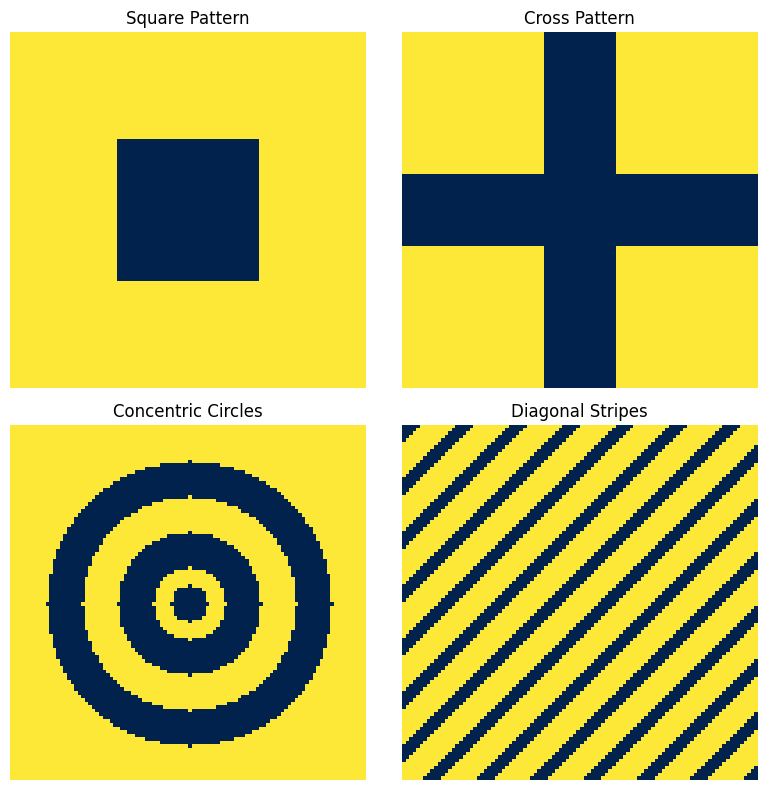

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define basic parameters
size = 100
bg_val = 0
pt_val = -2

# 1. Square pattern
arr_square = np.full((size, size), bg_val, dtype=int)
arr_square[30:70, 30:70] = pt_val

# 2. Cross pattern
arr_cross = np.full((size, size), bg_val, dtype=int)
arr_cross[40:60, :] = pt_val
arr_cross[:, 40:60] = pt_val

# 3. Concentric Circles (Bullseye) pattern
arr_concentric = np.full((size, size), bg_val, dtype=int)
Y, X = np.ogrid[:size, :size]
# Using squared distance to avoid floating point square roots
dist_sq = (X - 50)**2 + (Y - 50)**2

# Create alternating rings by defining min and max squared radii
# Outer ring (Radius between 30 and 40)
arr_concentric[(dist_sq <= 40**2) & (dist_sq > 30**2)] = pt_val
# Middle ring (Radius between 10 and 20)
arr_concentric[(dist_sq <= 20**2) & (dist_sq > 10**2)] = pt_val
# Center dot (Radius up to 5)
arr_concentric[dist_sq <= 5**2] = pt_val

# 4. Diagonal stripes pattern
arr_stripes = np.full((size, size), bg_val, dtype=int)
for i in range(size):
    for j in range(size):
        if (i + j) % 15 < 5:
            arr_stripes[i, j] = pt_val

# =========================
# Plotting the arrays
# =========================

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

patterns = [
    ("Square Pattern", arr_square),
    ("Cross Pattern", arr_cross),
    ("Concentric Circles", arr_concentric),
    ("Diagonal Stripes", arr_stripes)
]

for ax, (title, arr) in zip(axes.flatten(), patterns):
    im = ax.imshow(arr, cmap='cividis', vmin=-2, vmax=0)
    ax.set_title(title)
    ax.axis('off')



plt.tight_layout()
plt.show()

In [4]:
np.save('../data/masks/immunity_mask_square.npy', arr_square)
np.save('../data/masks/immunity_mask_cross.npy', arr_cross)
np.save('../data/masks/immunity_mask_concentric.npy', arr_concentric)
np.save('../data/masks/immunity_mask_stripes.npy', arr_stripes)

In [1]:
!python ../scripts/generate_data.py --output_dir ../data/simulations     --num_simulations 30 --grid_size 100 --timesteps 20 \
    --model_type epidemic     --p_transmission 0.2     --seed 42     --imumask ../data/masks/immunity_mask_cross.npy

  GÉNÉRATION DE DONNÉES - WaterberryFarms x N7 Projet Long
  Repertoire de sortie: ../data/simulations/generation_20260303_174031
  Nombre de simulations: 30
  Taille de grille: 100x100
  Pas de temps: 20
  Modele: epidemic
  Formats de sortie: images, graphs

Successfully loaded mask

[1/30] Génération de la simulation 0...

  Simulation 0: Exécution de 20 pas de temps...
{'simulation_id': 0, 'seed': 42, 'model_type': 'epidemic', 'grid_size': 100, 'timesteps': 20, 'parameters': {'p_transmission': 0.2, 'infection_duration': 5, 'spread_dimension': 11, 'infection_seeds': -1, 'dissipation_rate': None, 'p_pollution': None}, 'output_formats': ['images', 'graphs'], 'timestamp': '2026-03-03T17:40:31.408890'}
<class 'dict'>
{'simulation_id': 0, 'seed': 42, 'model_type': 'epidemic', 'grid_size': 100, 'timesteps': 20, 'parameters': {'p_transmission': 0.2, 'infection_duration': 5, 'spread_dimension': 11, 'infection_seeds': -1, 'dissipation_rate': None, 'p_pollution': None}, 'output_formats': ['im

In [ ]:
!python ../scripts/preprocess_data.py \
    --input ../data/simulations/generation_20260303_174031/ \
    --output ../data/processed \
    --add_spatial_features \
    --formats gnn \
    --normalize

  PRÉTRAITEMENT DES DONNÉES
  Entree: ../data/simulations/generation_20260303_174031
  Sortie: ../data/processed/processed_20260303_174737
  Formats: gnn
  Taille cible (CNN): 64x64
  Crop: False
  Normalisation: True

Traitement de 30 simulations...

[1/30] sim_0000
  20 timesteps traites                                                          
[2/30] sim_0001
  20 timesteps traites                                                          
[3/30] sim_0002
  20 timesteps traites                                                          
[4/30] sim_0003
  20 timesteps traites                                                          
[5/30] sim_0004
  20 timesteps traites                                                          
[6/30] sim_0005
  20 timesteps traites                                                          
[7/30] sim_0006
  20 timesteps traites                                                          
[8/30] sim_0007
  20 timesteps traites                               

In [5]:
!python ../scripts/create_datasets.py \
    --input ../data/processed/processed_20260303_174737/ \
    --train_ratio 0.7 \
    --val_ratio 0.15 \
    --test_ratio 0.15 \
    --stratify_by simulation \
    --create_sequences \
    --sequence_length 5 \
    --sequence_stride 1 \
    --seed 42

  CRÉATION DES DATASETS PYTORCH
  Entree: ../data/processed/processed_20260303_174737
  Sortie: ../data/processed/processed_20260303_174737/datasets
  Formats: gnn
  Split: 70% / 15% / 15%
  Stratification: simulation
  Seed: 42
  Sequences: longueur=5, stride=1


Collecte des paires (sim_id, timestep) unifiées...
{'nodes': array([[ 0,  0],
       [ 0,  1],
       [ 0,  2],
       ...,
       [99, 97],
       [99, 98],
       [99, 99]], dtype=int32), 'node_features': array([[1.  , 0.  , 0.  ],
       [1.  , 0.  , 0.01],
       [1.  , 0.  , 0.02],
       ...,
       [1.  , 0.99, 0.97],
       [1.  , 0.99, 0.98],
       [1.  , 0.99, 0.99]], dtype=float32), 'edges': array([[   0,    1],
       [   0,   80],
       [   1,    2],
       ...,
       [6396, 6397],
       [6397, 6398],
       [6398, 6399]], dtype=int32), 'shape': (100, 100), 'timestep': 0, 'node_status': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}
{'nodes': array([[ 0,  0],
       [ 0,  1],
       [ 0,  2],
       ...

Here we visualize the resulting graph. Expected output should be once again a graph that looks like a grid, only this time there are missing nodes corresponding to the immunity mask.

Successfully imported functions from visualize_dataset.py
   Nodes: 6400
   Edges: 12480
   Features Shape: (6400, 3)


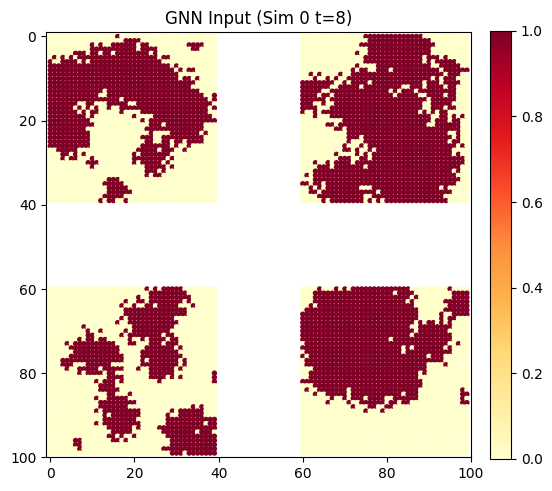

In [1]:
import sys
import os
import random
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(os.path.abspath("../scripts"))
try:
    from visualize_dataset import load_split, load_sample, get_cnn_image, get_gnn_data, _draw_graph, get_subgraph
    print("Successfully imported functions from visualize_dataset.py")
except ImportError as e:
    print(f"Error importing: {e}")
    print("Make sure 'visualize_dataset.py' is in the '../scripts/' folder.")

PROCESSED_DATA_PATH = "../data/processed/processed_20260303_145531"
DATA_ROOT = Path(PROCESSED_DATA_PATH)

gnn_split_path = DATA_ROOT / "datasets/gnn/train.json"
gnn_data = load_split(str(gnn_split_path)) #contains the json for train data

if gnn_data:
    # Pick a random sample
    sample_info = random.choice(gnn_data['samples'])
    
    # Handle path resolution
    file_path = Path(sample_info['file'])
    if not file_path.exists():
        file_path = DATA_ROOT / sample_info['file']

    # Load and Parse using imported functions
    data_dict = load_sample(str(file_path))
    gnn_components = get_gnn_data(data_dict)
    
    print(f"   Nodes: {len(gnn_components['nodes'])}")
    print(f"   Edges: {len(gnn_components['edges'])}")
    print(f"   Features Shape: {gnn_components['node_features'].shape}")

    # Plot using the existing _draw_graph function
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # _draw_graph modifies the axes object in-place
    _draw_graph(ax, gnn_components, cmap="YlOrRd")
    
    plt.title(f"GNN Input (Sim {sample_info['sim_id']} t={sample_info['timestep']})")
    plt.show()

Original Graph: 6400 nodes
Subgraph:       1600 nodes, 3120 edges


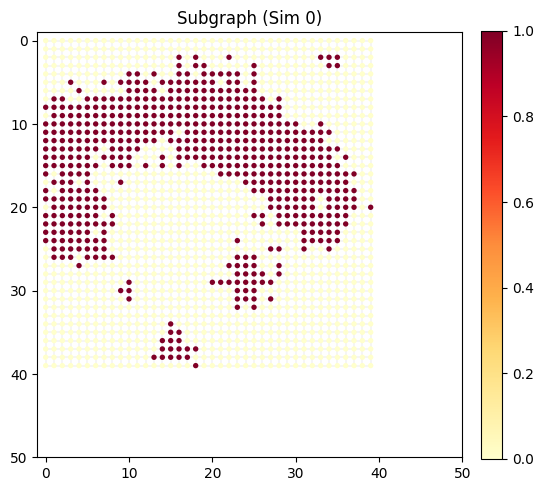

In [4]:
sample_info = random.choice(gnn_data['samples'])
    
    # Handle path resolution
file_path = Path(sample_info['file']) 
if not file_path.exists():
    file_path = DATA_ROOT / sample_info['file']

    # Load and Parse using imported functions
data_dict = load_sample(str(file_path))
gnn_components = get_gnn_data(data_dict)

subgraph = get_subgraph(gnn_components, x_max=50, y_max=50)

print(f"Original Graph: {len(gnn_components['nodes'])} nodes")
print(f"Subgraph:       {len(subgraph['nodes'])} nodes, {len(subgraph['edges'])} edges")

# 2. Pass it to the EXISTING visualize_dataset function
fig, ax = plt.subplots(figsize=(6, 6))

# This uses the imported function!
_draw_graph(ax, subgraph, cmap="YlOrRd") 

plt.title(f"Subgraph (Sim {sample_info['sim_id']})")
plt.show()

In [ ]:
!python ../scripts/train_gnn.py --cfg ../configs/gnn_config_temporal.yaml

In [ ]:
import sys
import os
# Ensure the parent directory is in the path so imports work correctly
sys.path.append(os.path.abspath('..')) 

# Import your function directly from the script
from scripts.visualize_gnn import plot_temporal_gnn_sample_n

# Run it
plot_temporal_gnn_sample_n(config_path="../configs/gnn_config_irr.yaml", n_samples=8)